# **Error Analysis - Video Games**


Note: the predictions get retourned as BPR loss. As consequence, the predictions are not in the range of 0 to 1. To interpret them further, we need to convert them to the range of 0 to 1. Use sigmoid function.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx

In [183]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_ego_hops(G, center_node, hops=2):
    """
    Draw the subgraph of G containing center_node plus all nodes
    at distance ≤ hops (first- and second-degree neighbors).
    """
    # 1) compute distances up to `hops`
    lengths = nx.single_source_shortest_path_length(G, center_node, cutoff=hops)
    # `lengths` maps node → distance (0 for center, 1 for neighbors, 2 for 2-hop)
    
    # 2) induce the subgraph
    nodes_within = list(lengths.keys())
    H = G.subgraph(nodes_within).copy()
    
    # 3) draw
    pos = nx.spring_layout(H)  # force-directed layout
    plt.figure(figsize=(8,8))
    
    # draw nodes, coloring by distance
    node_colors = [lengths[n] for n in H.nodes()]
    nx.draw_networkx_nodes(
        H, pos,
        node_size=300,
        cmap=plt.cm.viridis,
        node_color=node_colors,
        vmin=0, vmax=hops
    )
    # highlight edges connected to center node
    center_edges = list(H.edges(center_node))
    nx.draw_networkx_edges(
        H, pos,
        edgelist=center_edges,
        width=2.5,
        alpha=0.8,
        edge_color='red'
    )
    # draw edges
    nx.draw_networkx_edges(H, pos, alpha=0.5)
    
    # highlight the center node with a red border
    nx.draw_networkx_nodes(
        H, pos,
        nodelist=[center_node],
        node_size=500,
        edgecolors='red',
        linewidths=2,
    )
    
    # labels - adjust font size and add bbox for better readability
    labels = nx.draw_networkx_labels(
        H, pos,
        font_size=8,
        font_weight='bold',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1),
        horizontalalignment='center'
    )
    
    plt.title(f"Ego-graph of {center_node} (hops≤{hops})")
    plt.axis('off')
    plt.show()

# test use sigmoid function
def process_prediction(prediction_df):
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))
    
    prediction_df["prediction_sigmoid"] = sigmoid(prediction_df['prediction'])
    prediction_df["prediction_value"] = (prediction_df["prediction_sigmoid"] > 0.5).astype(int) # 1 if sigmoid > 0.5, otherwise 0
    return prediction_df

def count_hits(error_df):
    """
    Count hits and calculate accuracy metrics for prediction results.
    
    Args:
        error_df: DataFrame containing prediction results with 'prediction_value' and 'actual' columns
        
    Returns:
        DataFrame: The input DataFrame with additional columns for prediction metrics
    """
    # Add prediction correctness column
    error_df["prediction_correct"] = error_df["prediction_value"] == error_df["actual"]
    
    # Add positive and negative prediction columns
    error_df["prediction_positive"] = error_df["prediction_value"] == 1
    error_df["prediction_negative"] = error_df["prediction_value"] == 0
    
    # Print accuracy
    print(f"Accuracy in test set: {error_df['prediction_correct'].sum() / len(error_df)}")
    
    return error_df

def connect_parents(error_df, relation_df):
    error_df_item = error_df.copy()
    
    # merge first level parent
    error_df_item = error_df_item.merge(relation_df, left_on="item_id", right_on="head", how="left").rename(columns={"tail":"first_level_parent"})
    error_df_item.drop(columns=["head","relation","Unnamed: 0"], inplace=True)
    
    # merge second level parent
    error_df_item = error_df_item.merge(relation_df, left_on="first_level_parent", right_on="head", how="left").rename(columns={"tail":"second_level_parent"})
    error_df_item.drop(columns=["head","relation","Unnamed: 0"], inplace=True)
    
    # merge third level parent
    error_df_item = error_df_item.merge(relation_df, left_on="second_level_parent", right_on="head", how="left").rename(columns={"tail":"third_level_parent"})
    error_df_item.drop(columns=["head","relation","Unnamed: 0"], inplace=True)

    # merge fourth level parent
    error_df_item = error_df_item.merge(relation_df, left_on="third_level_parent", right_on="head", how="left").rename(columns={"tail":"fourth_level_parent"})
    error_df_item.drop(columns=["head","relation","Unnamed: 0"], inplace=True)

    return error_df_item


def map_ids_to_entities(df, mapping_df, df_type:str):
    if df_type == "relation":
        df["head"] = df["head"].map(mapping_df.set_index("id")["entity"])
        df["tail"] = df["tail"].map(mapping_df.set_index("id")["entity"])
    elif df_type == "error":
        df["item_id"] = df["item_id"].map(mapping_df.set_index("id")["entity"])
        df["user_id"] = df["user_id"].map(mapping_df.set_index("id")["entity"])
    return df


## **2. All Beauty**

### **2.1 Baseline (KGIL)**

In [184]:
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[1]
MODEL_TECHNIQUES = ["all-MiniLM-L6-v2","intfloat/multilingual-e5-large-instruct","Alibaba-NLP/gte-Qwen2-1.5B-instruct","gemma3", "ner","baseline"]
MODEL_TECHNIQUE = MODEL_TECHNIQUES[5]
MODEL_TECHNIQUE_NAME = MODEL_TECHNIQUE.replace("/", "_")

current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

EXPERIMENT_NAME = "#1"
EXPERIMENT_DATA_PATH = os.path.join(project_root,"experiments",EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

METADATA_PATH = os.path.join(project_root, 'preprocessed',DATASET)
TAXONOMY_PATH = os.path.join(project_root, 'taxonomy',DATASET)

baseline_error = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv")
baseline_mapping = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/entity_map.csv") # to convert ids to entity names
baseline_relation = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_relations.csv")
df_metadata = pd.read_csv(f"{METADATA_PATH}/metadata_filtered_df.csv") # contains the metadata for items
df_test = pd.read_csv(f"{METADATA_PATH}/test_df.csv") # contains the test set
df_train = pd.read_csv(f"{METADATA_PATH}/train_df.csv") # contains the train set

In [185]:
baseline_mapping

,entity,id
0,AFSKPY37N3C43SOI5IEXEK5JSIYA,0
1,AHV6QCNBJNSGLATP56JAWJ3C4G2A,1
2,AFJBKPK5W56XWSNPQU2WW66ISWYQ,2
3,AFXF3EGQTQDXMRLDWFU7UBFQZB7Q,3
4,AFWVN52MRBWOTIK7UGXBWGOY4HBA,4
...,...,...
571,B09G22586Y,571
572,B0BVQQ58G8,572
573,B0B4MR9BXN,573
574,B08HVRP54L,574


In [186]:
baseline_error

,user_id,item_id,prediction,actual
0,14,0,-0.364843,0
1,14,1,-0.155503,0
2,14,2,1.015970,0
3,14,3,0.759315,0
4,14,4,0.463298,0
...,...,...,...,...
10345,239,570,0.638788,0
10346,239,571,-1.675966,0
10347,239,572,0.788809,0
10348,239,573,-0.535250,0


In [187]:
baseline_error = map_ids_to_entities(baseline_error, baseline_mapping,"error")
baseline_relation = map_ids_to_entities(baseline_relation, baseline_mapping,"relation")
baseline_relation

,Unnamed: 0,head,relation,tail
0,0,AFSKPY37N3C43SOI5IEXEK5JSIYA,0,B07J3GH1W1
1,1,AFSKPY37N3C43SOI5IEXEK5JSIYA,0,B07W397QG4
2,2,AFSKPY37N3C43SOI5IEXEK5JSIYA,0,B07KG1TWP5
3,3,AFSKPY37N3C43SOI5IEXEK5JSIYA,0,B08JTNQFZY
4,4,AFSKPY37N3C43SOI5IEXEK5JSIYA,0,B07SLFWZKN
...,...,...,...,...
2254,2254,AGQIUTI7M4XUGCRV6E66FAOCX5PQ,0,B08DK5D9J5
2255,2255,AGOLMT3QETKYNESRYKBA6D7XXS7A,0,B0BVQQ58G8
2256,2256,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,0,B0BVQQ58G8
2257,2257,AEMP3A7IKW37CMWFXNKXWW6HGJHA_1,0,B0B4MR9BXN


In [192]:
# filter df_error by df_test
baseline_error = baseline_error[baseline_error["user_id"].isin(df_test["user_id"])]
baseline_error = baseline_error[baseline_error["item_id"].isin(df_test["parent_asin"])]
baseline_error = baseline_error.sort_values(by=["user_id","prediction"], ascending=True)
baseline_error

,user_id,item_id,prediction,actual,prediction_sigmoid,prediction_value,prediction_correct,prediction_positive,prediction_negative
3411,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B086GST51S,-1.012345,0,0.266521,0,True,False,True
3379,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08DK5D9J5,-0.580787,0,0.358751,0,True,False,True
3259,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B07PBWVV5K,-0.289366,0,0.428159,0,True,False,True
3447,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B0BVQQ58G8,-0.259174,1,0.435567,0,False,False,True
3313,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B07JGD2T2J,-0.055102,0,0.486228,0,True,False,True
...,...,...,...,...,...,...,...,...,...
9161,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B086GST51S,-0.038376,0,0.490407,0,True,False,True
9009,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B07PBWVV5K,0.135547,0,0.533835,1,False,True,False
9052,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B083J1Y349,0.145945,0,0.536422,1,False,True,False
9063,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B07JGD2T2J,0.169043,0,0.542160,1,False,True,False


In [189]:
print(baseline_error["actual"].value_counts())


actual
0    162
1     18
Name: count, dtype: int64


In [190]:
baseline_error = process_prediction(baseline_error)
baseline_error = count_hits(baseline_error)
baseline_error

Accuracy in test set: 0.5166666666666667


,user_id,item_id,prediction,actual,prediction_sigmoid,prediction_value,prediction_correct,prediction_positive,prediction_negative
3411,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B086GST51S,-1.012345,0,0.266521,0,True,False,True
3379,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08DK5D9J5,-0.580787,0,0.358751,0,True,False,True
3259,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B07PBWVV5K,-0.289366,0,0.428159,0,True,False,True
3447,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B0BVQQ58G8,-0.259174,1,0.435567,0,False,False,True
3313,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B07JGD2T2J,-0.055102,0,0.486228,0,True,False,True
...,...,...,...,...,...,...,...,...,...
9161,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B086GST51S,-0.038376,0,0.490407,0,True,False,True
9009,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B07PBWVV5K,0.135547,0,0.533835,1,False,True,False
9052,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B083J1Y349,0.145945,0,0.536422,1,False,True,False
9063,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B07JGD2T2J,0.169043,0,0.542160,1,False,True,False


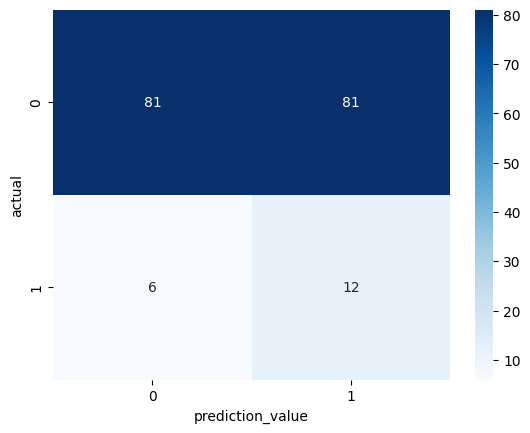

In [191]:
# confusion matrix
confusion_matrix = pd.crosstab(baseline_error["actual"], baseline_error["prediction_value"])

# draw confusion matrix
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.show()


The confusion matrix shows that the model is more likely to predict a negative hit (0) than a positive hit (1). The model predicts 93 observations as positive and 89 as negative. This seems to be fairly balanced. The likelihood to predict a positive right is double the likelihood to predict a positive wrong.


In [193]:
baseline_error_item = connect_parents(baseline_error, baseline_relation)
baseline_error_item["fourth_level_parent"].value_counts()


Series([], Name: count, dtype: int64)

### **2.2 LLM-COL-HIERARCHY-TAX (gemma3)**

In [40]:
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[1]
MODEL_TECHNIQUES = ["all-MiniLM-L6-v2","intfloat/multilingual-e5-large-instruct","Alibaba-NLP/gte-Qwen2-1.5B-instruct","gemma3", "ner","baseline"]
MODEL_TECHNIQUE = MODEL_TECHNIQUES[3]
MODEL_TECHNIQUE_NAME = MODEL_TECHNIQUE.replace("/", "_")


EXPERIMENT_NAME = "#1"
EXPERIMENT_DATA_PATH = os.path.join(project_root,"experiments",EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

gemma_error = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv") # contains the predictions
gemma_mapping = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/entity_map.csv") # to convert ids to entity names
gemma_relation = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_taxonomy-triples.csv") # contains the relations between items and hierarhcy


In [41]:
gemma_error["user_id"] = gemma_error["user_id"].map(gemma_mapping.set_index("id")["entity"])
gemma_error["item_id"] = gemma_error["item_id"].map(gemma_mapping.set_index("id")["entity"])

# filter df_error by df_test
gemma_error = gemma_error[gemma_error["user_id"].isin(df_test["user_id"])]
gemma_error = gemma_error[gemma_error["item_id"].isin(df_test["parent_asin"])]
gemma_error = gemma_error.sort_values(by=["user_id","prediction"], ascending=True)
gemma_error

,user_id,item_id,prediction,actual
3572,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B09G22586Y,-0.009263,0
3575,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08HVRP54L,0.037056,0
3294,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B086GST51S,0.077502,0
3574,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B0B4MR9BXN,0.097304,0
3573,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B0BVQQ58G8,0.109583,1
...,...,...,...,...
9534,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B0B4MR9BXN,0.058689,0
9455,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B07PBWVV5K,0.349996,0
9235,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B08F79Z1Q5,0.597278,0
9258,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B07JGD2T2J,0.813325,0


In [42]:
print(gemma_error["actual"].value_counts())


actual
0    161
1     19
Name: count, dtype: int64


In [43]:
gemma_error = process_prediction(gemma_error)
gemma_error = count_hits(gemma_error)
gemma_error


Accuracy in test set: 0.46111111111111114


,user_id,item_id,prediction,actual,prediction_sigmoid,prediction_value,prediction_correct,prediction_positive,prediction_negative
3572,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B09G22586Y,-0.009263,0,0.497684,0,True,False,True
3575,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08HVRP54L,0.037056,0,0.509263,1,False,True,False
3294,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B086GST51S,0.077502,0,0.519366,1,False,True,False
3574,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B0B4MR9BXN,0.097304,0,0.524307,1,False,True,False
3573,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B0BVQQ58G8,0.109583,1,0.527368,1,True,True,False
...,...,...,...,...,...,...,...,...,...
9534,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B0B4MR9BXN,0.058689,0,0.514668,1,False,True,False
9455,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B07PBWVV5K,0.349996,0,0.586617,1,False,True,False
9235,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B08F79Z1Q5,0.597278,0,0.645033,1,False,True,False
9258,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B07JGD2T2J,0.813325,0,0.692817,1,False,True,False


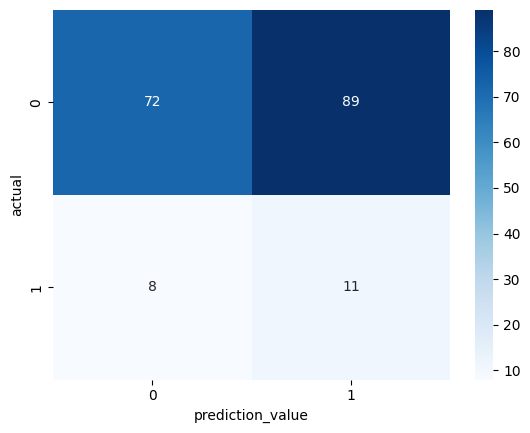

In [44]:
# confusion matrix
confusion_matrix = pd.crosstab(gemma_error["actual"], gemma_error["prediction_value"])

# draw confusion matrix
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.show()


The model with the llm-col-hierarchy-tax constructed by the LLM gemma3 shows for the user-item pairs in the test set a `low accuracy of 0.46`. Looking at the confusion matrix, we can see that the model is slighlty more likely to predict a negative hit (0) than a positive hit (1). Addtionaly the model tends to predict a lot of values as positive, which are actually negative. The model predicts only 8 observations as negative, which are actually positive. In total 100 observations are predicted as positive and 80 are predicted as negative. This seam to be fairly balanced. Also the `errors seem to be distributed evenly`. As next step, we can look at the errors and see if there are any patterns.


To observe the errors and identify patterns we want to look for an item entity all the relations in the taxonomy that are connected to it.

In [45]:
gemma_error_item = connect_parents(gemma_error, gemma_relation)

In [46]:
gemma_error_item["fourth_level_parent"].value_counts()

Series([], Name: count, dtype: int64)

Taxonomy only three levels deep

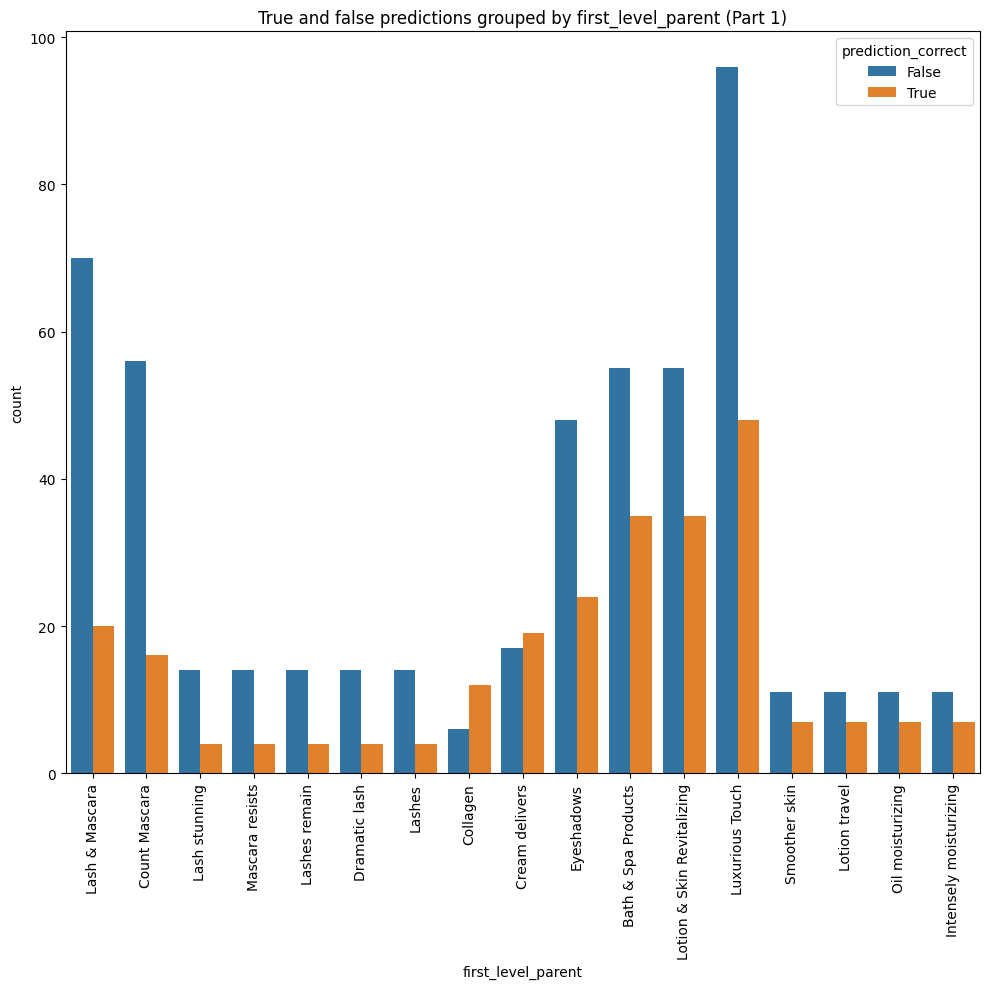

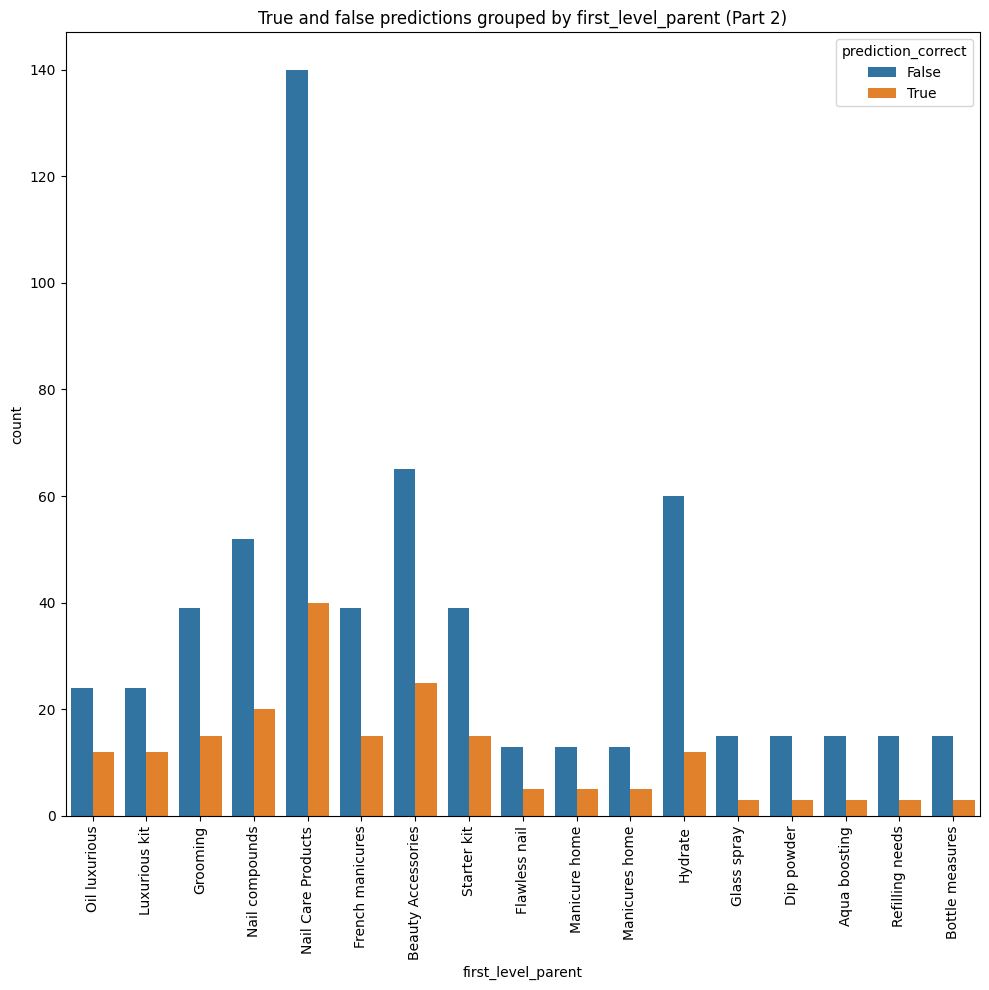

In [256]:
# Get unique first_level_parent values and split them into two groups
first_level_parents = gemma_error_item['first_level_parent'].dropna().unique()
half_idx = len(first_level_parents) // 2
first_half = first_level_parents[:half_idx]
second_half = first_level_parents[half_idx:]

# First plot - first half of first_level_parents
plt.figure(figsize=(10, 10))
plt.title("True and false predictions grouped by first_level_parent (Part 1)")
plt.xlabel("first_level_parent")
plt.ylabel("count")
sns.countplot(x="first_level_parent", hue="prediction_correct", 
              data=gemma_error_item[gemma_error_item['first_level_parent'].isin(first_half)])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Second plot - second half of first_level_parents
plt.figure(figsize=(10, 10))
plt.title("True and false predictions grouped by first_level_parent (Part 2)")
plt.xlabel("first_level_parent")
plt.ylabel("count")
sns.countplot(x="first_level_parent", hue="prediction_correct", 
              data=gemma_error_item[gemma_error_item['first_level_parent'].isin(second_half)])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

It is visile that prediciton errors for items direct connections to an entity of the taxonomy are not evenly distributed. A lot of false occur for nail products (like nail compounds, nail care products), mascaras or luxury touch

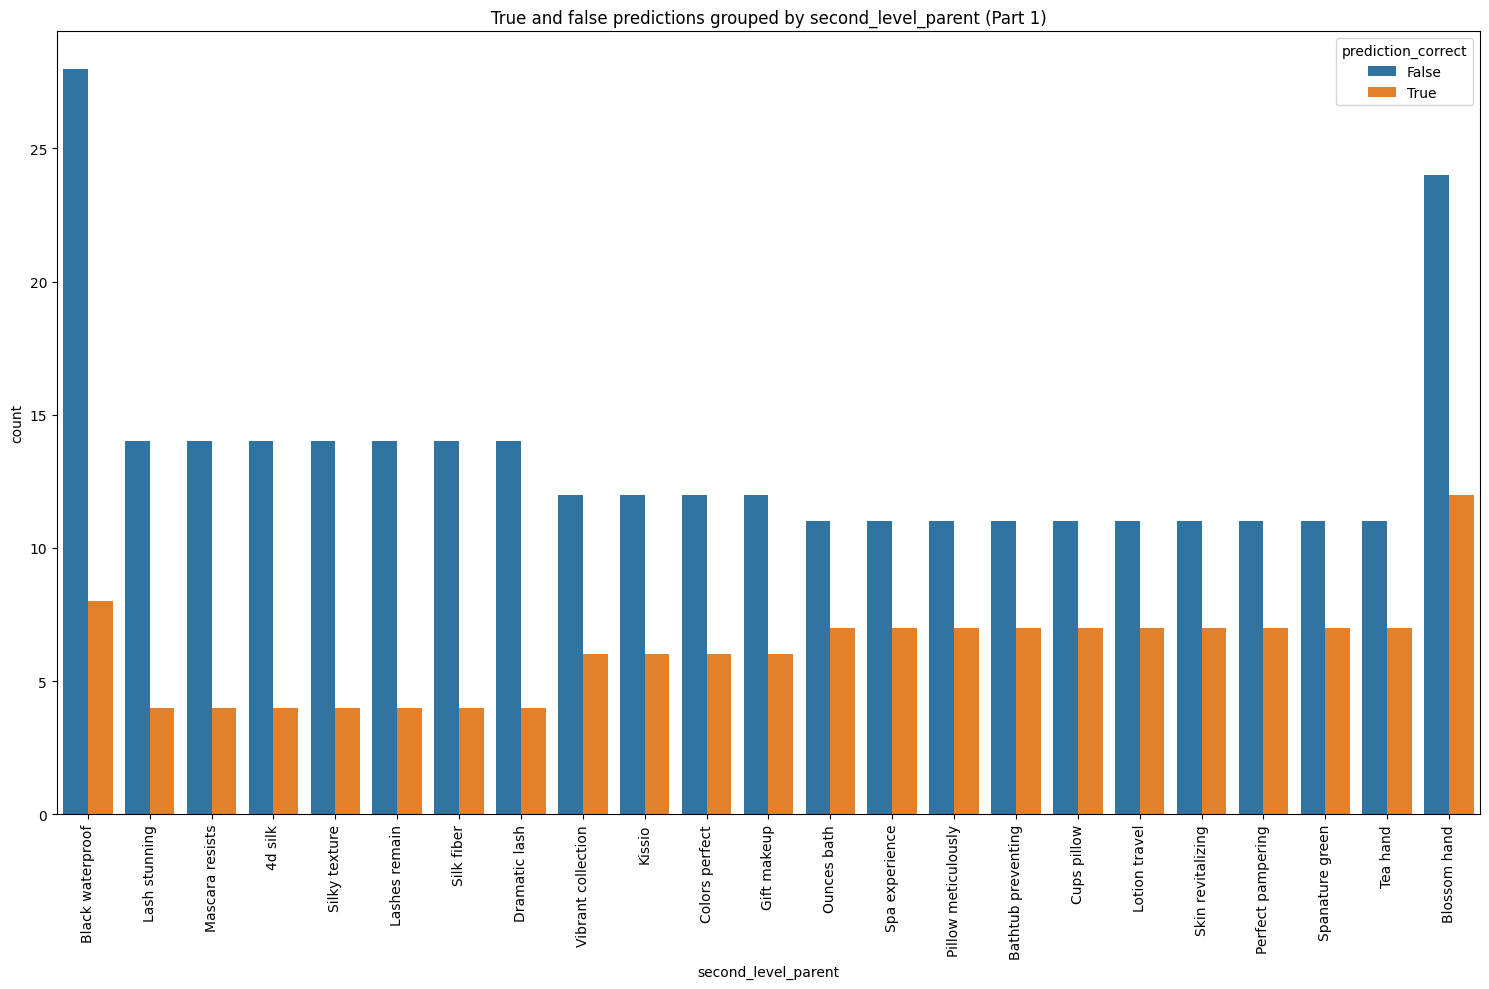

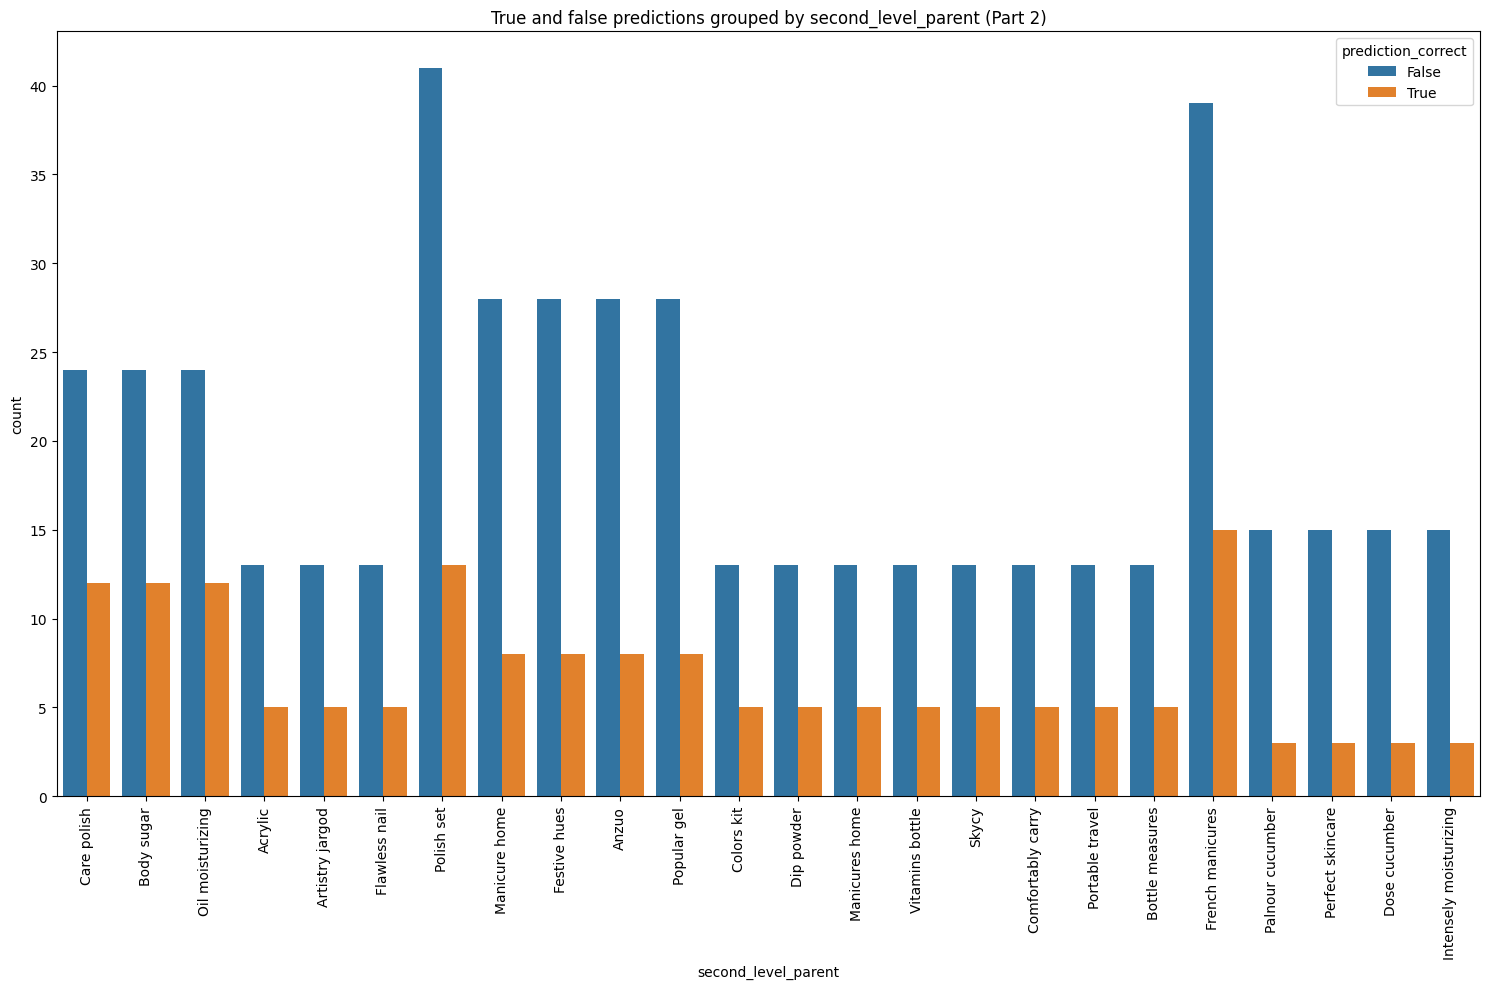

In [229]:
# second level parent - split into two plots for better readability
# Get unique second_level_parent values and split them into two groups
second_level_parents = gemma_error_item['second_level_parent'].dropna().unique()
half_idx = len(second_level_parents) // 2
first_half = second_level_parents[:half_idx]
second_half = second_level_parents[half_idx:]

# First plot - first half of second_level_parents
plt.figure(figsize=(15, 10))
plt.title("True and false predictions grouped by second_level_parent (Part 1)")
plt.xlabel("second_level_parent")
plt.ylabel("count")
sns.countplot(x="second_level_parent", hue="prediction_correct", 
              data=gemma_error_item[gemma_error_item['second_level_parent'].isin(first_half)])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Second plot - second half of second_level_parents
plt.figure(figsize=(15, 10))
plt.title("True and false predictions grouped by second_level_parent (Part 2)")
plt.xlabel("second_level_parent")
plt.ylabel("count")
sns.countplot(x="second_level_parent", hue="prediction_correct", 
              data=gemma_error_item[gemma_error_item['second_level_parent'].isin(second_half)])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

we see for second_level_parent that the model predicts a lot of values false for items related to manigure and nail items (e.g french manicure, polish set, etc.) or related to specific feature (e.g. black waterproof)

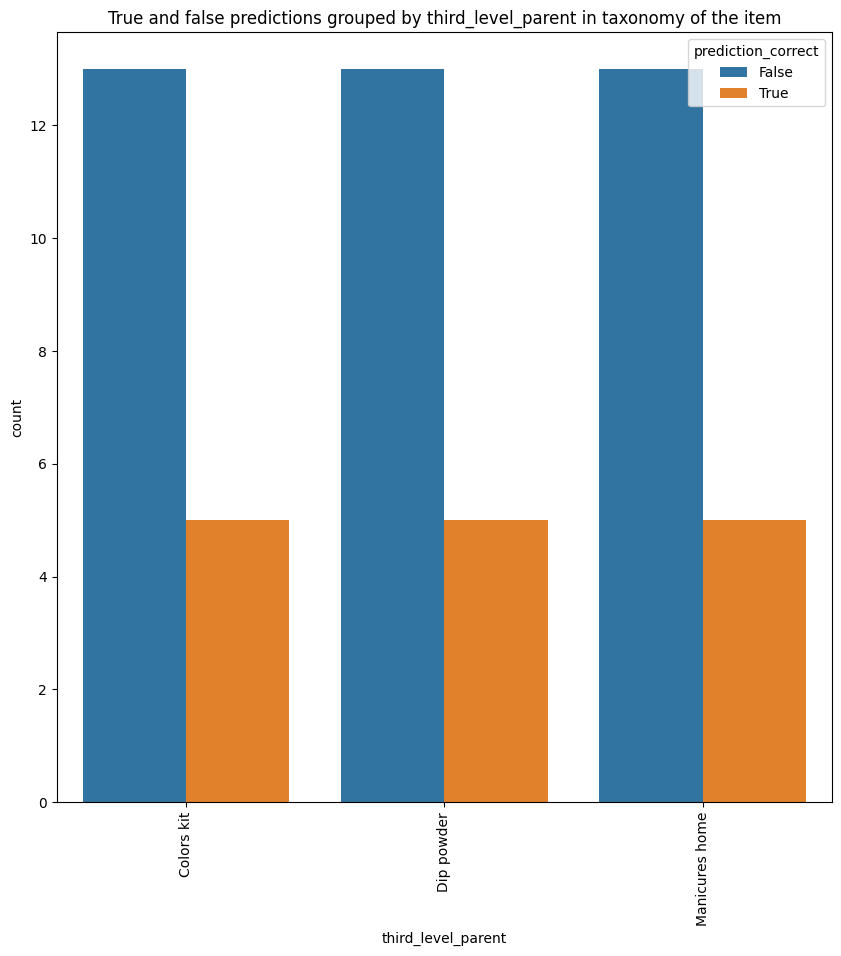

In [230]:
# third level parent
plt.figure(figsize=(10, 10))
plt.title("True and false predictions grouped by third_level_parent in taxonomy of the item")
plt.xlabel("third_level_parent")
plt.ylabel("count")
sns.countplot(x="third_level_parent", hue="prediction_correct", data=gemma_error_item)
plt.xticks(rotation=90)
plt.show()

On the third and last level of the taxonomy, we see that the model evenly predicts true and false for the items related to the category "colors kit", "dip powder", and "manicurer home".
This indicates that the model likely has issues on lower levels of the taxonomy for predicting items.

To understand the errors better in the next step we want to look at the taxonomy graph and see how items are connected to the taxonomy. This might help find suboptimal subgraphs, redundancies or issues with curtain depth of the taxonomy.

In [231]:
gemma_error_item.head()
wrong_prediction = pd.DataFrame(gemma_error_item[gemma_error_item["prediction_correct"] == False])
wrong_prediction 

,user_id,item_id,prediction,actual,prediction_sigmoid,prediction_value,prediction_correct,prediction_positive,prediction_negative,first_level_parent,second_level_parent,third_level_parent,fourth_level_parent
1,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08HVRP54L,0.037056,0,0.509263,1,False,True,False,NaN,NaN,NaN,NaN
2,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B086GST51S,0.077502,0,0.519366,1,False,True,False,Lash & Mascara,Black waterproof,NaN,NaN
3,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B086GST51S,0.077502,0,0.519366,1,False,True,False,Lash & Mascara,Lash stunning,NaN,NaN
4,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B086GST51S,0.077502,0,0.519366,1,False,True,False,Lash & Mascara,Mascara resists,NaN,NaN
5,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B086GST51S,0.077502,0,0.519366,1,False,True,False,Lash & Mascara,4d silk,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1633,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B083J1Y349,0.849251,0,0.700410,1,False,True,False,Manicure home,NaN,NaN,NaN
1634,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B083J1Y349,0.849251,0,0.700410,1,False,True,False,Manicures home,NaN,NaN,NaN
1635,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B083J1Y349,0.849251,0,0.700410,1,False,True,False,Grooming,NaN,NaN,NaN
1636,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B083J1Y349,0.849251,0,0.700410,1,False,True,False,Oil luxurious,NaN,NaN,NaN


In [212]:
wrong_prediction_item = df_metadata[df_metadata["parent_asin"] == wrong_prediction["item_id"].tail(1).iloc[0]]
wrong_prediction_item = wrong_prediction_item["parent_asin"].iloc[0]


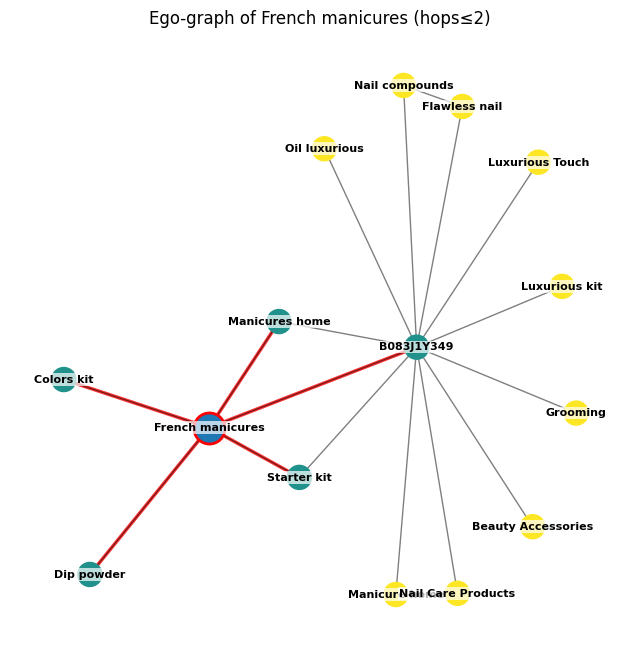

In [289]:
gemma_relation_wo_products = gemma_relation[
    (~gemma_relation["head"].str.startswith("B0") | gemma_relation["head"].str.contains(wrong_prediction_item)) & 
    ~gemma_relation["head"].str.startswith("A")
]

g_taxonomy = nx.from_pandas_edgelist(gemma_relation_wo_products, source='head', target='tail') 
draw_ego_hops(g_taxonomy, center_node="French manicures", hops=2)

As we can see the product has redundant relations to the taxonomy. The product is related to the category "French manicures", "starter kit" and "manicure homes". The releations are that way because they product keywords extracted have similiar embeddings to the corresponding taxonomy categories. This just give an indice but does not explain the systematic errors.

In [214]:
df_metadata["categories"].value_counts()

Series([], Name: count, dtype: int64)

In [233]:


# df_relation without items except the wrong prediction
gemma_relation_filtered = gemma_relation[~gemma_relation["head"].isin([wrong_prediction["item_id"], wrong_prediction["first_level_parent"], wrong_prediction["second_level_parent"], wrong_prediction["third_level_parent"], wrong_prediction["fourth_level_parent"]])]

#filter out the items from df_relation_filtered starting with "B0" or "A", except B08HVRP54L

gemma_relation_filtered = gemma_relation_filtered[~gemma_relation_filtered["tail"].str.startswith("B0") & ~gemma_relation_filtered["tail"].str.startswith("A")]
# add the user_id and item_id and relation from wrong_prediction to the df_relation_filtered
# In newer pandas versions, append() is deprecated. Use concat() or pd.DataFrame.from_records() instead
new_row = pd.DataFrame([{"head": wrong_prediction["user_id"].iloc[0], "tail": wrong_prediction["item_id"].iloc[0], "relation": "wrong_prediction"}])
gemma_relation_filtered = pd.concat([gemma_relation_filtered, new_row], ignore_index=True).reset_index(drop=True)
gemma_relation_filtered.tail()

,Unnamed: 0,head,relation,tail
2392,2445.0,B087GD4BJ1,related to,Dramatic lash
2393,2446.0,B087GD4BJ1,related to,Lashes
2394,2447.0,B087GD4BJ1,related to,Oil luxurious
2395,2448.0,B087GD4BJ1,related to,Luxurious kit
2396,NaN,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,wrong_prediction,B08HVRP54L


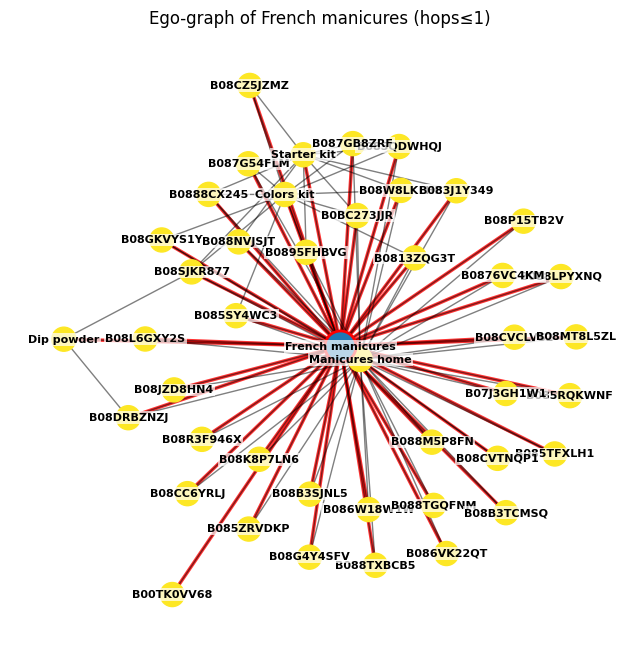

In [245]:


# Create graph from relationship dataframe
G = nx.from_pandas_edgelist(gemma_relation_filtered, source='head', target='tail')
draw_ego_hops(G, center_node="French manicures", hops=1)

As we can see most of the items are connected to the category "French manicures" and also the category "starter kit" and "manicure homes". This is likely the reason why the model predicts a lot of items as positive, which are actually negative. To test this hypothesis we calculate the number of items that are connected to the category "French manicures" and the category "starter kit" and "manicure homes".

In [250]:
number_of_items_connected_to_french_manicures = len(gemma_relation_filtered[gemma_relation_filtered["tail"] == "French manicures"])
number_of_items_connected_to_starter_kit = len(gemma_relation_filtered[gemma_relation_filtered["tail"] == "Starter kit"])
number_of_items_connected_to_manicure_homes = len(gemma_relation_filtered[gemma_relation_filtered["tail"] == "Manicure home"])

print(f"Number of items connected to French manicures: {number_of_items_connected_to_french_manicures}")
print(f"Number of items connected to starter kit: {number_of_items_connected_to_starter_kit}")
print(f"Number of items connected to manicure homes: {number_of_items_connected_to_manicure_homes}")

Number of items connected to French manicures: 40
Number of items connected to starter kit: 23
Number of items connected to manicure homes: 40


The output of the cell above shows how many items are connected to the category "French manicures" and the category "starter kit" and "manicure homes". We can see that there are 40 items connected to "French manicures" and 23 items connected to "starter kit" and 40 items connected to "manicure homes". This indicates that this taxonomy of french manicures and manicures home is highly redundant and the child node french manicures doesnt provide any additional information. 

Further we observe if the path of Nail care products to Manicure home is valuable or redundant.

In [265]:
gemma_relation_filtered[gemma_relation_filtered["tail"] == "Nail Care Products"].head(2)

,Unnamed: 0,head,relation,tail
35,40.0,Product details,is parent of,Nail Care Products
155,169.0,B088M5P8FN,related to,Nail Care Products


In [275]:
wrong_product_nail_care_products = gemma_relation_filtered[gemma_relation_filtered["tail"] == "Nail Care Products"].iloc[2]["head"]
wrong_product_nail_care_products


'B08HZ5Y8RY'

In [280]:
gemma_error_item[gemma_error_item["first_level_parent"] == "Nail Care Products"].head(50)

,user_id,item_id,prediction,actual,prediction_sigmoid,prediction_value,prediction_correct,prediction_positive,prediction_negative,first_level_parent,second_level_parent,third_level_parent,fourth_level_parent
50,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B083J1Y349,1.018990,0,0.734776,1,False,True,False,Nail Care Products,Manicure home,NaN,NaN
51,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B083J1Y349,1.018990,0,0.734776,1,False,True,False,Nail Care Products,Festive hues,NaN,NaN
52,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B083J1Y349,1.018990,0,0.734776,1,False,True,False,Nail Care Products,Polish set,NaN,NaN
53,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B083J1Y349,1.018990,0,0.734776,1,False,True,False,Nail Care Products,Anzuo,NaN,NaN
54,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B083J1Y349,1.018990,0,0.734776,1,False,True,False,Nail Care Products,Popular gel,NaN,NaN
76,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08F79Z1Q5,1.538935,0,0.823310,1,False,True,False,Nail Care Products,Manicure home,NaN,NaN
77,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08F79Z1Q5,1.538935,0,0.823310,1,False,True,False,Nail Care Products,Festive hues,NaN,NaN
78,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08F79Z1Q5,1.538935,0,0.823310,1,False,True,False,Nail Care Products,Polish set,NaN,NaN
79,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08F79Z1Q5,1.538935,0,0.823310,1,False,True,False,Nail Care Products,Anzuo,NaN,NaN
80,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08F79Z1Q5,1.538935,0,0.823310,1,False,True,False,Nail Care Products,Popular gel,NaN,NaN


In [284]:
gemma_error[gemma_error["item_id"] == "B08F79Z1Q5"]

,user_id,item_id,prediction,actual,prediction_sigmoid,prediction_value,prediction_correct,prediction_positive,prediction_negative
3275,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08F79Z1Q5,1.538935,0,0.823310,1,False,True,False
7447,AE5GH4VM5Q5HNUL4EOAYRLNB7RVA,B08F79Z1Q5,0.738242,0,0.676611,1,False,True,False
9831,AEMP3A7IKW37CMWFXNKXWW6HGJHA_1,B08F79Z1Q5,0.800498,0,0.690081,1,False,True,False
10427,AETJVSLQFY2F7D5AZ7H4ONORPQEQ_1,B08F79Z1Q5,0.429620,0,0.605783,1,False,True,False
5063,AFNACT4MLU243POBVE666TFVUPGQ,B08F79Z1Q5,-0.107534,0,0.473142,0,True,False,True
4467,AFPMVI6ZRR7KS7AWRIBCKILWDVIA,B08F79Z1Q5,0.382050,0,0.594367,1,False,True,False
6255,AFTJ7XQN2EIELHARUBBL6Y7L65DA,B08F79Z1Q5,0.760425,1,0.681446,1,True,True,False
2679,AG7WXYJR3N3IOL7NX6QUZJUPBVDA,B08F79Z1Q5,0.794507,0,0.688798,1,False,True,False
3871,AGLLAOO4MTOC5RG6EIUCOSK4XXXA,B08F79Z1Q5,-0.229701,0,0.442826,0,True,False,True
8639,AGOLMT3QETKYNESRYKBA6D7XXS7A,B08F79Z1Q5,0.279504,0,0.569425,1,False,True,False


As we can see the product for product "B08F79Z1Q5" the majority of predicitons are positive, eventough just 1 out of 19 observations in test set are actually positive. 

In [291]:
print(f"Occurences of items in train set: {len(df_train[df_train['parent_asin'] == 'B08F79Z1Q5'])}")
print(f"Occurences of items in test set: {len(df_test[df_test['parent_asin'] == 'B083J1Y349'])}")

print(f"% occurences of items in train set: {len(df_train[df_train['parent_asin'] == 'B08F79Z1Q5']) / len(df_train)}")
print(f"% occurences of items in test set: {len(df_test[df_test['parent_asin'] == 'B083J1Y349']) / len(df_test)}")


Occurences of items in train set: 4
Occurences of items in test set: 1
% occurences of items in train set: 0.001788109074653554
% occurences of items in test set: 0.045454545454545456


We see that the item itself isnt either overrepresented in the train or test set. so the model is likely not tend to predcit popularity bias

In [300]:
# all items from french manicures 
df_relation_french_manicures = gemma_relation_filtered[gemma_relation_filtered["tail"] == "French manicures"]
french_manicures_items = df_train[df_train["parent_asin"].isin(df_relation_french_manicures["head"])]

print(f"% occurences of items related to french manicures in train set: {len(french_manicures_items) / len(df_train)}")
print(f"% occurences of items related to french manicures in test set: {len(df_test[df_test['parent_asin'].isin(df_relation_french_manicures["head"])]) / len(df_test)}")


df_relation_nail_care_products = gemma_relation_filtered[gemma_relation_filtered["tail"] == "Nail Care Products"]

print(f"% occurences of items related to nail care products in train set: {len(df_train[df_train['parent_asin'].isin(df_relation_nail_care_products["head"])]) / len(df_train)}")
print(f"% occurences of items related to nail care products in test set: {len(df_test[df_test['parent_asin'].isin(df_relation_nail_care_products["head"])]) / len(df_test)}")


% occurences of items related to french manicures in train set: 0.13902548055431382
% occurences of items related to french manicures in test set: 0.045454545454545456
% occurences of items related to nail care products in train set: 0.16763522574877068
% occurences of items related to nail care products in test set: 0.09090909090909091


We dont see an overrepresentation of items related to french manicures or nail care products in the train or test set. So the model is not biased towards popularity. Means its more likely the model is confused by the redundancy of this part of the taxonomy.